In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

Load The Data

In [2]:
df = pd.read_excel(r"C:\Users\MOHIT JHA\Desktop\Customer Churn Prediction\Telco_customer_churn.xlsx\Telco_customer_churn.xlsx")

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [5]:
drop_cols = [
    'CustomerID',   # Unique ID (no value)
    'Count',        # constant
    'Country',      # same for all
    'State',        # mostly same
    'Lat Long',     # not useful
    'Latitude',
    'Longitude',
    'Zip Code',
    'Churn Label',  # duplicate of target
    'Churn Score',  # DATA LEAKAGE ❌
    'CLTV',         # future info ❌
    'Churn Reason'  # only known AFTER churn ❌
]

df = df.drop(columns=drop_cols)

In [6]:
df['Churn Value']

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64

In [7]:
df.rename(columns={'Churn Value': 'Churn'}, inplace=True)

<Axes: xlabel='Churn', ylabel='count'>

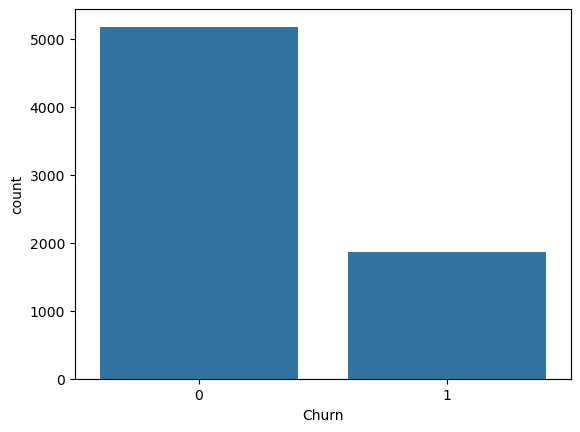

In [8]:
df['Churn'].value_counts()
sns.countplot(x='Churn', data=df)

In [9]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [10]:
df.isnull().sum()

City                  0
Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn                 0
dtype: int64

In [11]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [12]:
df.isnull().sum()

City                 0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn                0
dtype: int64

In [13]:
df.replace({'Yes':1, 'No':0}, inplace=True)

C:\Users\MOHIT JHA\AppData\Local\Temp\ipykernel_8676\241966483.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Yes':1, 'No':0}, inplace=True)


In [14]:
df = pd.get_dummies(df, drop_first=True)

Before Modeling

<Axes: xlabel='Churn', ylabel='Monthly Charges'>

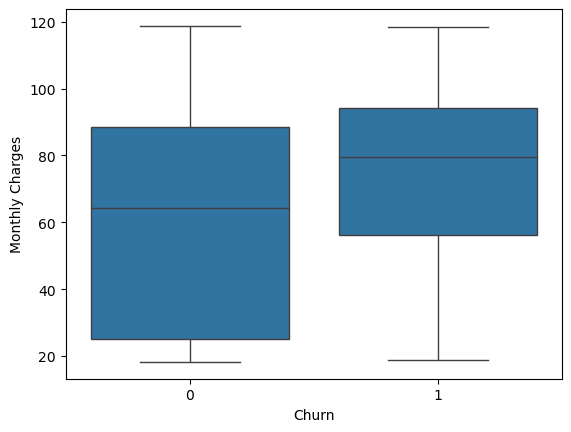

In [15]:
sns.boxplot(x='Churn', y='Monthly Charges', data=df)

<Axes: xlabel='Contract_One year', ylabel='count'>

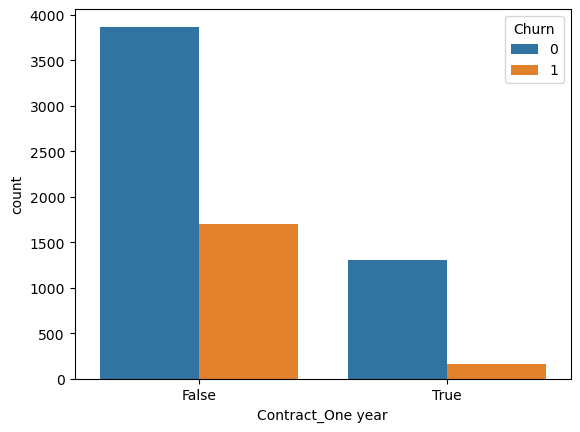

In [16]:
sns.countplot(x='Contract_One year', hue='Churn', data=df)

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
y_train.value_counts()

Churn
0    4165
1    1469
Name: count, dtype: int64

In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

c:\ANa\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

c:\ANa\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:30:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [26]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

def evaluate(model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))

In [27]:
evaluate(lr)
evaluate(rf)
evaluate(xgb)

Accuracy: 0.7693399574166075
AUC: 0.8333275520317146
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1009
           1       0.59      0.61      0.60       400

    accuracy                           0.77      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.77      0.77      0.77      1409

Accuracy: 0.7963094393186657
AUC: 0.8439519326065411
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1009
           1       0.65      0.62      0.64       400

    accuracy                           0.80      1409
   macro avg       0.75      0.74      0.75      1409
weighted avg       0.79      0.80      0.80      1409

Accuracy: 0.7927608232789212
AUC: 0.8462561942517345
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1009
           1       0.63      0.64      0.64       400

    accuracy           

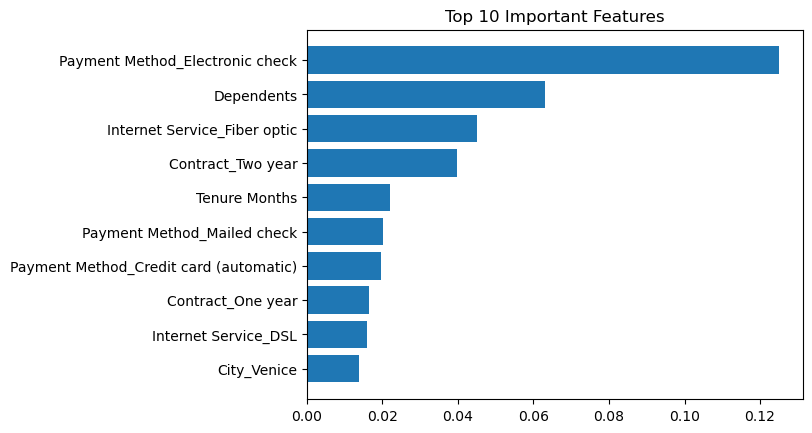

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

importances = xgb.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [30]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1]
}

grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\ANa\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:33:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\ANa\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:33:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\ANa\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:33:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\ANa\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:33:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\ANa\Lib\site-packages\xgboost\training.py

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200], 'subsample': [0.8, 1]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [31]:
best_model = grid.best_estimator_

In [32]:
evaluate(best_model)

Accuracy: 0.7991483321504613
AUC: 0.8527613974231912
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1009
           1       0.64      0.66      0.65       400

    accuracy                           0.80      1409
   macro avg       0.75      0.76      0.76      1409
weighted avg       0.80      0.80      0.80      1409

